# SOFA score:
The Sequential Organ Failure Assessment (SOFA) score is a scoring system used to assess the severity of organ dysfunction in critically ill patients. It is widely used in intensive care units (ICUs) to monitor and predict patient outcomes.
SOFA is designed to quantify the extent of organ dysfunction in critically ill patients over time. It helps clinicians assess the severity of illness, predict mortality risk, and guide treatment decisions.
SOFA evaluates organ dysfunction in six organ systems:

Respiratory: PaO2/FiO2 ratio or Oxygen saturation pulse oximetry.
Coagulation: Platelet count or INR.
Liver: Bilirubin level.
Cardiovascular: Mean arterial pressure or vasopressor use.
Central Nervous System (CNS): Glasgow Coma Scale score.
Renal: Serum creatinine or urine output.

Each organ system is assigned a score ranging from 0 to 4 based on the degree of dysfunction. Higher scores indicate more severe dysfunction. The total SOFA score is the sum of individual scores from each organ system, with a maximum score of 24.

![SOFA score table](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEiUPLgbPaDbGh3VgNJ6Uhz05Re8bFQQ6ByxoRMEG4QT5eJpHbOe4MC8de-p7YVCoy_dxMlrHX4UYByJjZCBMM3NaU4-jn3mvK-zdhv6uGqQwPU7vgbNRH-7JDpNlBwKgwQNWp5woVcBiWI/s1600/sofa.jpg)

In [ ]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.feather as feather
import os
import random

In [2]:
parent_folder = os.path.dirname(os.getcwd())
sibling_folder = os.path.join(parent_folder,'data')
processed_folder = os.path.join(sibling_folder, 'processed')

In [3]:
# Data loading and feature selection for calculation of SOFA score
feather_file_path = os.path.join(processed_folder, 'icu_timeseries_features_0M_0ed859c799267d4ae737f8814d52726d_20240512.feather')
df = feather.read_feather(feather_file_path)

columns_to_keep = [
    'abs_event_time', 'stay_id', 'O2 saturation pulseoxymetry',
    'Arterial Blood Pressure mean', 'Bilirubin, Total', 'Platelet Count',
    'Creatinine', 'GCS - Eye Opening', 'GCS - Motor Response', 'GCS - Verbal Response'
]
df = df[columns_to_keep]
df['abs_event_time'] = pd.to_datetime(df['abs_event_time'])

In [4]:
# Calculation of SOFA score
calculate_SOFA = lambda SpO2, gcs_eye_opening, gcs_motor_response, gcs_verbal_response, platelet_count, bilirubin, mean_arterial_pressure, creatinine: (
    4 if SpO2 < 90 else
    3 if SpO2 < 92 else
    2 if SpO2 < 94 else
    1 if SpO2 < 96 else
    0
) + (
    4 if mean_arterial_pressure < 40 else
    3 if mean_arterial_pressure < 50 else
    2 if mean_arterial_pressure < 60 else
    1 if mean_arterial_pressure < 70 else
    0
) + (
    4 if bilirubin >= 12.0 else
    3 if bilirubin >= 6.0 else
    2 if bilirubin >= 2.0 else
    1 if bilirubin >= 1.2 else
    0
) + (
    4 if platelet_count <= 20 else
    3 if platelet_count <= 50 else
    2 if platelet_count <= 100 else
    1 if platelet_count <= 150 else
    0
) + (
    4 if creatinine > 5 else
    3 if 3.5 <= creatinine <= 4.9 else
    2 if 2.0 <= creatinine <= 3.4 else
    1 if 1.2 <= creatinine <= 1.9 else
    0
) + (
    4 if gcs_eye_opening + gcs_motor_response + gcs_verbal_response < 6 else
    3 if gcs_eye_opening + gcs_motor_response + gcs_verbal_response < 10 else
    2 if gcs_eye_opening + gcs_motor_response + gcs_verbal_response < 13 else
    1 if gcs_eye_opening + gcs_motor_response + gcs_verbal_response < 15 else
    0
)

In [5]:

df_ffilled = df.ffill().bfill()

df_ffilled['SOFA_score'] = df_ffilled.apply(
    lambda row: calculate_SOFA(
        row['O2 saturation pulseoxymetry'],
        row['GCS - Eye Opening'],
        row['GCS - Motor Response'],
        row['GCS - Verbal Response'],
        row['Platelet Count'],
        row['Bilirubin, Total'],
        row['Arterial Blood Pressure mean'],
        row['Creatinine']
    ), axis=1
)


In [6]:
#Generating random StayID and creating legends for the plot
low_threshold = 10
high_threshold = 22
random_stay_id = random.choice(df_ffilled['stay_id'])

filtered_df = df_ffilled[df_ffilled['stay_id'] == random_stay_id].copy()
bins = [-float('inf'), low_threshold, high_threshold, float('inf')]
labels = ['Low', 'Moderate', 'High']
filtered_df['score_category'] = pd.cut(filtered_df['SOFA_score'], bins=bins, labels=labels, right=False)


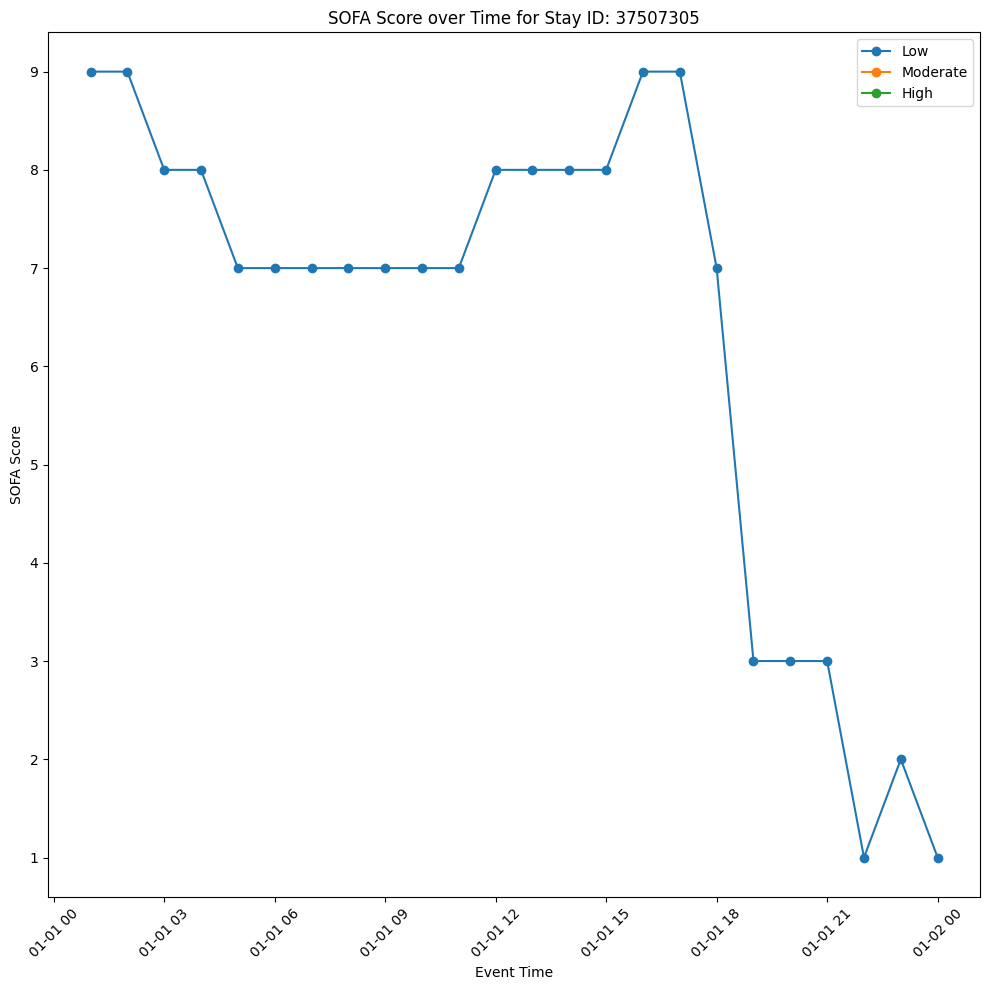

In [7]:
#Plotting the SOFA score over time for a random StayID
plt.figure(figsize=(10, 10))

for category, group in filtered_df.groupby('score_category', observed=False):
    plt.plot(group['abs_event_time'], group['SOFA_score'], marker='o', linestyle='-', label=category)
plt.ylabel('SOFA Score')
plt.xlabel('Event Time')
plt.title(f'SOFA Score over Time for Stay ID: {random_stay_id}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()